In [13]:
"""Imports"""
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [14]:
"""Constants"""
TANK_RADIUS_1T_mm = 525
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [15]:
"""Functions"""
def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data

def calc_radius(x, y):
    """Simple stuff"""
    return (x**2 + y**2)**0.5

def get_delta_radius(data, entry_or_exit: str) -> list[float]:
    delta_radius_list = []
    num_events = len(data)
    for i in range(num_events):
        if not throughgoing(data[i]):
            continue
        if entry_or_exit == "entry":
            reco_x = data[i]["reco"][0]
            reco_y = data[i]["reco"][1]
            true_x = data[i]["truth"][0]
            true_y = data[i]["truth"][1]
        elif entry_or_exit == "exit":
            reco_x = data[i]["reco"][2]
            reco_y = data[i]["reco"][3]
            true_x = data[i]["truth"][2]
            true_y = data[i]["truth"][3]
        dist = np.sqrt((reco_x - true_x)**2 + (reco_y - true_y)**2)
#         if dist > 1000:
#             print(reco_x, true_x, reco_y, true_y)
        delta_radius_list.append(dist)
    return delta_radius_list

def get_cos_theta(data) -> list[float]:
    cos_theta_list = []
    num_events = len(data)
    for i in range(num_events):
#         if not throughgoing(data[i]):
#             continue
        reco_x_entry = data[i]["reco"][0]
        reco_y_entry = data[i]["reco"][1]
        true_x_entry = data[i]["truth"][0]
        true_y_entry = data[i]["truth"][1]
        reco_x_exit = data[i]["reco"][2]
        reco_y_exit = data[i]["reco"][3]
        true_x_exit = data[i]["truth"][2]
        true_y_exit = data[i]["truth"][3]

        true_vec = np.array([true_x_exit, true_y_exit, TANK_BOTTOM_Z_mm]) - np.array([true_x_entry, true_y_entry, TANK_TOP_Z_mm])
        reco_vec = np.array([reco_x_exit, reco_y_exit, TANK_BOTTOM_Z_mm]) - np.array([reco_x_entry, reco_y_entry, TANK_TOP_Z_mm])

        true_normalized = true_vec / np.linalg.norm(true_vec)
        reco_normalized = reco_vec / np.linalg.norm(reco_vec)
        
        dot_product = np.dot(true_normalized, reco_normalized)
        cos_theta_list.append(dot_product)
#         if dot_product < 0:
#             print(reco_x_entry, reco_y_entry, true_x_entry, true_y_entry, reco_x_exit, reco_y_exit, true_x_exit, true_y_exit)
    return cos_theta_list

def majority_trigger(event) -> bool:
    """Index into the 26th hit. If it is one of the 28 bottom PMTs, we know
    this is a majority trigger event."""
    pmt_num = event["hits"][25][4]
    if pmt_num <= 28:
        return True
    return False

def throughgoing(event) -> bool:
    """Returns a bool if reco points are within top and bottom bases of 
    cylindrical detector, because this implies they did not enter/exit side"""
    true_x_entry = event["truth"][0]
    true_y_entry = event["truth"][1]
    true_x_exit = event["truth"][2]
    true_y_exit = event["truth"][3]
    if (calc_radius(true_x_entry, true_y_entry) < TANK_RADIUS_1T_mm) and (calc_radius(true_x_exit, true_y_exit) < TANK_RADIUS_1T_mm):
        return True
    return False

In [16]:
# fileee = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_all/reco_elosstank_digit_weight_all_91.pkl"
# fileee = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/numCher_digit_weight_per_reco_91.pkl"
fileee = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_per/numCher_digit_edge_per_reco_91.pkl"
data = load_data(fileee)

2426
2426


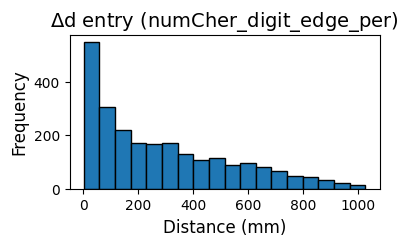

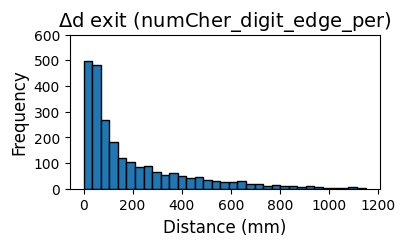

In [17]:
values = get_delta_radius(data, "entry")
print(len(values))
# Create the histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Distance (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(r'$\Delta$d entry (numCher_digit_edge_per)', fontsize=14)

# Show the plot
# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/wbls_sim_delta_d_entry_numCher_digit_edge_per.png", dpi=300, bbox_inches="tight")

values = get_delta_radius(data, "exit")
print(len(values))
# Create the histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Distance (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yticks([0,100,200,300,400,500,600])
plt.title(r'$\Delta$d exit (numCher_digit_edge_per)', fontsize=14)

# Show the plot
# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/wbls_sim_delta_d_exit_numCher_digit_edge_per.png", dpi=300, bbox_inches="tight")

22.26056073442773


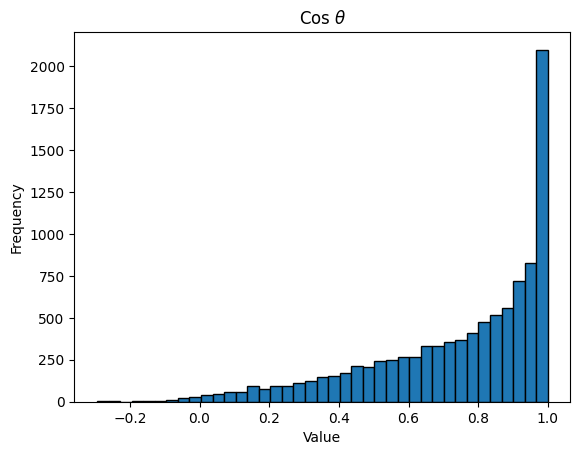

In [18]:
values = get_cos_theta(data)

cos_theta_68 = np.percentile(values, 68)
theta_rad = np.arccos(cos_theta_68)
theta_deg = np.degrees(theta_rad)
print(theta_deg)

# Create the histogram
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(r'Cos $\theta$')

# Show the plot
plt.show()